<a href="https://colab.research.google.com/github/Animesh-Maiti/NayanSagar_2.O/blob/main/NayanSagar_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os
import shutil

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Install dependencies
!pip install -q ultralytics opencv-python-headless matplotlib pyyaml

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 7.2 MB/s eta 0:00:00


In [ ]:
import zipfile
import yaml

zip_path = '/content/drive/MyDrive/NayanSagar_AI/NayanSagar_Dataset_v1.zip'
extract_dir = '/content/dataset'

print("[*] Unzipping dataset directly to local Colab NVMe SSD...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Update YAML path pointing to local extracted folder
yaml_path = '/content/dataset/sonar_data.yaml'
with open(yaml_path, 'r') as f:
    cfg = yaml.safe_load(f)

cfg['path'] = '/content/dataset'
cfg['train'] = 'images/train'
cfg['val'] = 'images/val'

with open(yaml_path, 'w') as f:
    yaml.dump(cfg, f)

print("[✓] Dataset successfully staged:")
print(open(yaml_path).read())

[*] Unzipping dataset directly to local Colab NVMe SSD...
[✓] Dataset successfully staged:
names:
  0: shipwreck
  1: aircraft_wreck
  2: crab_pot_trap
  3: ghost_net
  4: debris_highlight
  5: acoustic_shadow
path: /content/dataset
train: images/train
val: images/val



In [ ]:
import os
import shutil
from pathlib import Path
import yaml

dataset_root = Path('/content/dataset')
print("[*] Rebuilding real Linux directory tree from Windows pathnames...")

# Find all files with backslashes in their names and move them to proper paths
count = 0
for file_path in list(dataset_root.iterdir()):
    if '\\' in file_path.name:
        # Convert 'images\train\sample.png' -> ['images', 'train', 'sample.png']
        parts = file_path.name.split('\\')
        target_dest = dataset_root.joinpath(*parts)
        target_dest.parent.mkdir(parents=True, exist_ok=True)
        shutil.move(str(file_path), str(target_dest))
        count += 1

print(f"[✓] Restructured {count} files into standard directories.")

# Verify the folders now exist
train_imgs = list((dataset_root / 'images' / 'train').glob('*'))
val_imgs = list((dataset_root / 'images' / 'val').glob('*'))
print(f"[✓] Train images found: {len(train_imgs)}")
print(f"[✓] Val images found: {len(val_imgs)}")

# Write clean absolute sonar_data.yaml
yaml_path = '/content/sonar_data.yaml'
data_cfg = {
    'path': '/content/dataset',
    'train': 'images/train',
    'val': 'images/val',
    'names': {
        0: 'shipwreck',
        1: 'aircraft_wreck',
        2: 'crab_pot_trap',
        3: 'ghost_net',
        4: 'debris_highlight',
        5: 'acoustic_shadow'
    }
}

with open(yaml_path, 'w') as f:
    yaml.dump(data_cfg, f, default_flow_style=False)

print(f"[✓] Configuration successfully created at {yaml_path}")

[*] Rebuilding real Linux directory tree from Windows pathnames...
[✓] Restructured 15032 files into standard directories.
[✓] Train images found: 6012
[✓] Val images found: 1504
[✓] Configuration successfully created at /content/sonar_data.yaml


In [ ]:
import os
import shutil
from pathlib import Path
from ultralytics import YOLO

# 1. Load the pre-trained small segmentation model
model = YOLO('yolo11s-seg.pt')

# 2. Launch training with acoustic physics augmentations
results = model.train(
    data='/content/sonar_data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    amp=True,
    # Sonar-specific augmentations
    hsv_h=0.0,       # Turn off hue (sonar is single-channel/grayscale)
    hsv_s=0.0,       # Turn off saturation
    hsv_v=0.25,      # Acoustic gain variations (simulates TVG falloff)
    fliplr=0.5,      # Port/starboard swath symmetry
    flipud=0.2,      # Along-track vessel travel variance
    mosaic=0.5,      # Multi-target spatial mixing
    project='/content/runs',
    name='yolo11s_sonar_segmentation',
    exist_ok=True,
    save=True,
    plots=True
)

# 3. Locate best checkpoint dynamically
save_dir = Path(results.save_dir)
best_pt = save_dir / 'weights' / 'best.pt'
print(f"\n[✓] Training complete. Local weights saved at: {best_pt}")

# 4. Export to ONNX for edge deployment
trained_model = YOLO(str(best_pt))
trained_model.export(format='onnx', dynamic=True, simplify=True)
best_onnx = save_dir / 'weights' / 'best.onnx'

# 5. Mirror artifacts to Google Drive to ensure persistence
drive_dest = Path('/content/drive/MyDrive/NayanSagar_AI/runs/yolo11s_sonar_segmentation/weights')
drive_dest.mkdir(parents=True, exist_ok=True)

if best_pt.exists():
    shutil.copy(best_pt, drive_dest / 'best.pt')
    print(f"[✓] Backed up best.pt to: {drive_dest / 'best.pt'}")

if best_onnx.exists():
    shutil.copy(best_onnx, drive_dest / 'best.onnx')
    print(f"[✓] Backed up best.onnx to: {drive_dest / 'best.onnx'}")

# Copy validation plots & confusion matrix
for plot_file in save_dir.glob('*.png'):
    shutil.copy(plot_file, drive_dest.parent / plot_file.name)
print("[✓] Diagnostic charts and metrics copied to Drive.")

Ultralytics 8.4.143 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/sonar_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.25, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=yolo11s_sonar_segmentation, nbs=64, nms=None, ops

version_2


In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import zipfile

# 1. Verify/remount drive cleanly
try:
    !ls -l /content/drive/MyDrive > /dev/null
except Exception:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

# 2. Paths
drive_zip = '/content/drive/MyDrive/NayanSagar_AI/NayanSagar_Dataset_v2_Balanced.zip'
local_zip = '/content/dataset.zip'
extract_path = '/content/dataset'

# 3. Clean local destination
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)
os.makedirs(extract_path, exist_ok=True)

# 4. Stream copy from Drive to local VM scratch space (robust chunked copy)
print("Copying ZIP archive to local NVMe scratch disk...")
!cp "{drive_zip}" "{local_zip}"

# 5. Extract locally (fast, native NVMe I/O with zero Drive FUSE timeouts)
print("Extracting dataset from local NVMe...")
!unzip -q "{local_zip}" -d "{extract_path}"

# 6. Remove the local zip to free VM storage
if os.path.exists(local_zip):
    os.remove(local_zip)

print("Extraction complete. Checking folder structure:")
!ls -lh /content/dataset

Copying ZIP archive to local NVMe scratch disk...
Extracting dataset from local NVMe...
Extraction complete. Checking folder structure:
total 4.0K
drwxr-xr-x 4 root root 4.0K Sep  9 07:02 balanced_unified_v2


In [ ]:
import os
import shutil
from pathlib import Path
import yaml

# Move nested contents directly into /content/dataset/
nested_dir = Path('/content/dataset/balanced_unified_v2')
root_dir = Path('/content/dataset')

if nested_dir.exists():
    for item in nested_dir.iterdir():
        dest = root_dir / item.name
        if dest.exists():
            if dest.is_dir():
                shutil.rmtree(dest)
            else:
                dest.unlink()
        shutil.move(str(item), str(dest))
    shutil.rmtree(nested_dir)
    print("[✓] Flattened balanced_unified_v2 into /content/dataset")

# Verify contents
print("\nDataset root listing:")
!ls -lh /content/dataset

# Verify image & label counts
train_imgs = len(list(Path('/content/dataset/images/train').glob('*.*')))
val_imgs   = len(list(Path('/content/dataset/images/val').glob('*.*')))
train_lbls = len(list(Path('/content/dataset/labels/train').glob('*.txt')))
val_lbls   = len(list(Path('/content/dataset/labels/val').glob('*.txt')))

print(f"\nTrain set: {train_imgs} images, {train_lbls} label files")
print(f"Val set:   {val_imgs} images, {val_lbls} label files")
assert train_imgs == 5570 and val_imgs == 983, "Split count mismatch!"
print("[✓] Counts match expected 5,570 train and 983 val records.")

[✓] Flattened balanced_unified_v2 into /content/dataset

Dataset root listing:
total 12K
drwxr-xr-x 4 root root 4.0K Sep  9 07:02 images
drwxr-xr-x 4 root root 4.0K Sep  9 07:02 labels
-rw-rw-rw- 1 root root  166 Sep  9  2026 sonar_data_v2.yaml

Train set: 5570 images, 5570 label files
Val set:   983 images, 983 label files
[✓] Counts match expected 5,570 train and 983 val records.


In [ ]:
from ultralytics import YOLO

# 1. Initialize official pretrained weights
model = YOLO('yolo11s-seg.pt')

# 2. Start training with acoustic sonar hyperparameter tuning
results = model.train(
    data='/content/dataset/sonar_data_v2.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=4,
    patience=15,
    save=True,
    project='/content/drive/MyDrive/NayanSagar_AI/runs',
    name='yolo11s_balanced_v2',
    # Rare-class balancing augmentations
    copy_paste=0.3,    # Injects rare ghost net and aircraft instances into training tiles
    mosaic=1.0,        # Contextual multi-target composition
    mixup=0.1,         # Prevents overfitting on homogenous seabed textures
    # Hydrographic sonar physics constraints
    fliplr=0.5,        # Across-track horizontal symmetry (port <-> starboard)
    flipud=0.0,        # Locked: prevents flipping acoustic shadows toward the nadir
    degrees=10.0,      # Towfish yaw jitter tolerance
    # Loss balance
    box=7.5,
    cls=0.5,
    dfl=1.5
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.144 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/sonar_data_v2.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=to

In [ ]:
# 1. Mount Google Drive
from google.colab import drive
import os, shutil
from pathlib import Path

drive.mount('/content/drive')

# Verify shared folder shortcut exists
drive_base = Path('/content/drive/MyDrive/NayanSagar_AI')
assert drive_base.exists(), "Cannot find NayanSagar_AI shortcut in My Drive! Make sure you added the shortcut."

# 2. Setup local NVMe scratch storage
local_dataset = Path('/content/dataset')
if local_dataset.exists():
    shutil.rmtree(local_dataset)
local_dataset.mkdir(parents=True, exist_ok=True)

# 3. Fast copy to VM disk & native unpack
print("Copying balanced dataset archive to VM...")
!cp "/content/drive/MyDrive/NayanSagar_AI/NayanSagar_Dataset_v2_Balanced.zip" "/content/dataset.zip"

print("Extracting dataset...")
!unzip -q "/content/dataset.zip" -d "/content/dataset"
os.remove("/content/dataset.zip")

# Flatten nested folder if unzipped with subfolder
nested = Path('/content/dataset/balanced_unified_v2')
if nested.exists():
    for item in nested.iterdir():
        shutil.move(str(item), f'/content/dataset/{item.name}')
    nested.rmdir()

# 4. Install Ultralytics
!pip install -q "ultralytics>=8.3.0"

# 5. Quick parity check
train_count = len(list(Path('/content/dataset/images/train').glob('*.*')))
val_count = len(list(Path('/content/dataset/images/val').glob('*.*')))
print(f"[✓] Dataset ready on NVMe: {train_count} train images, {val_count} val images.")

Mounted at /content/drive
Copying balanced dataset archive to VM...
Extracting dataset...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 7.5 MB/s eta 0:00:00
[✓] Dataset ready on NVMe: 5570 train images, 983 val images.


In [ ]:
import torch
from ultralytics import YOLO
from pathlib import Path

checkpoint_path = '/content/drive/MyDrive/NayanSagar_AI/runs/yolo11s_balanced_v2/weights/last.pt'
assert Path(checkpoint_path).exists(), f"Checkpoint not found at: {checkpoint_path}"

# 1. Load checkpoint to inspect saved epoch and update local dataset path
ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
saved_epoch = ckpt.get('epoch', 'Unknown')
print(f"Checkpoint successfully loaded! Resuming from epoch index: {saved_epoch}")

# 2. Re-point data arg to local scratch space
ckpt['train_args']['data'] = '/content/dataset/sonar_data_v2.yaml'
torch.save(ckpt, checkpoint_path)
print("[✓] Checkpoint args patched to local /content/dataset/sonar_data_v2.yaml")

# 3. Resume training seamlessly
model = YOLO(checkpoint_path)
model.train(resume=True)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Checkpoint successfully loaded! Resuming from epoch index: 23
[✓] Checkpoint args patched to local /content/dataset/sonar_data_v2.yaml
Ultralytics 8.4.144 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/sonar_data_v2.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0,

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e7da9b8b310>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,  

In [ ]:
from google.colab import drive
import os
from pathlib import Path

# Mount Drive if starting a fresh session
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Locate trained weights
run_dir = Path('/content/drive/MyDrive/NayanSagar_AI/runs/yolo11s_balanced_v2')
weights_dir = run_dir / 'weights'
best_pt = weights_dir / 'best.pt'

assert best_pt.exists(), f"Error: Cannot find best.pt at {best_pt}"
print(f"[✓] Found best.pt ({best_pt.stat().st_size / (1024*1024):.2f} MB)")

Mounted at /content/drive
[✓] Found best.pt (19.57 MB)


In [ ]:
!pip install -q "ultralytics>=8.3.0" onnx onnxslim

from ultralytics import YOLO

print("Loading best.pt for ONNX compilation...")
model = YOLO(str(best_pt))

# Export to ONNX with opset 12 and graph simplification
onnx_file = model.export(
    format='onnx',
    imgsz=640,
    opset=12,
    simplify=True,
    dynamic=False
)

print(f"\n[✓] ONNX export complete! Saved to: {onnx_file}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.0/239.0 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 7.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Loading best.pt for ONNX compilation...
Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO11s-seg summary (fused)

Found 117 pure Side-Scan Sonar (SSS) target candidates.


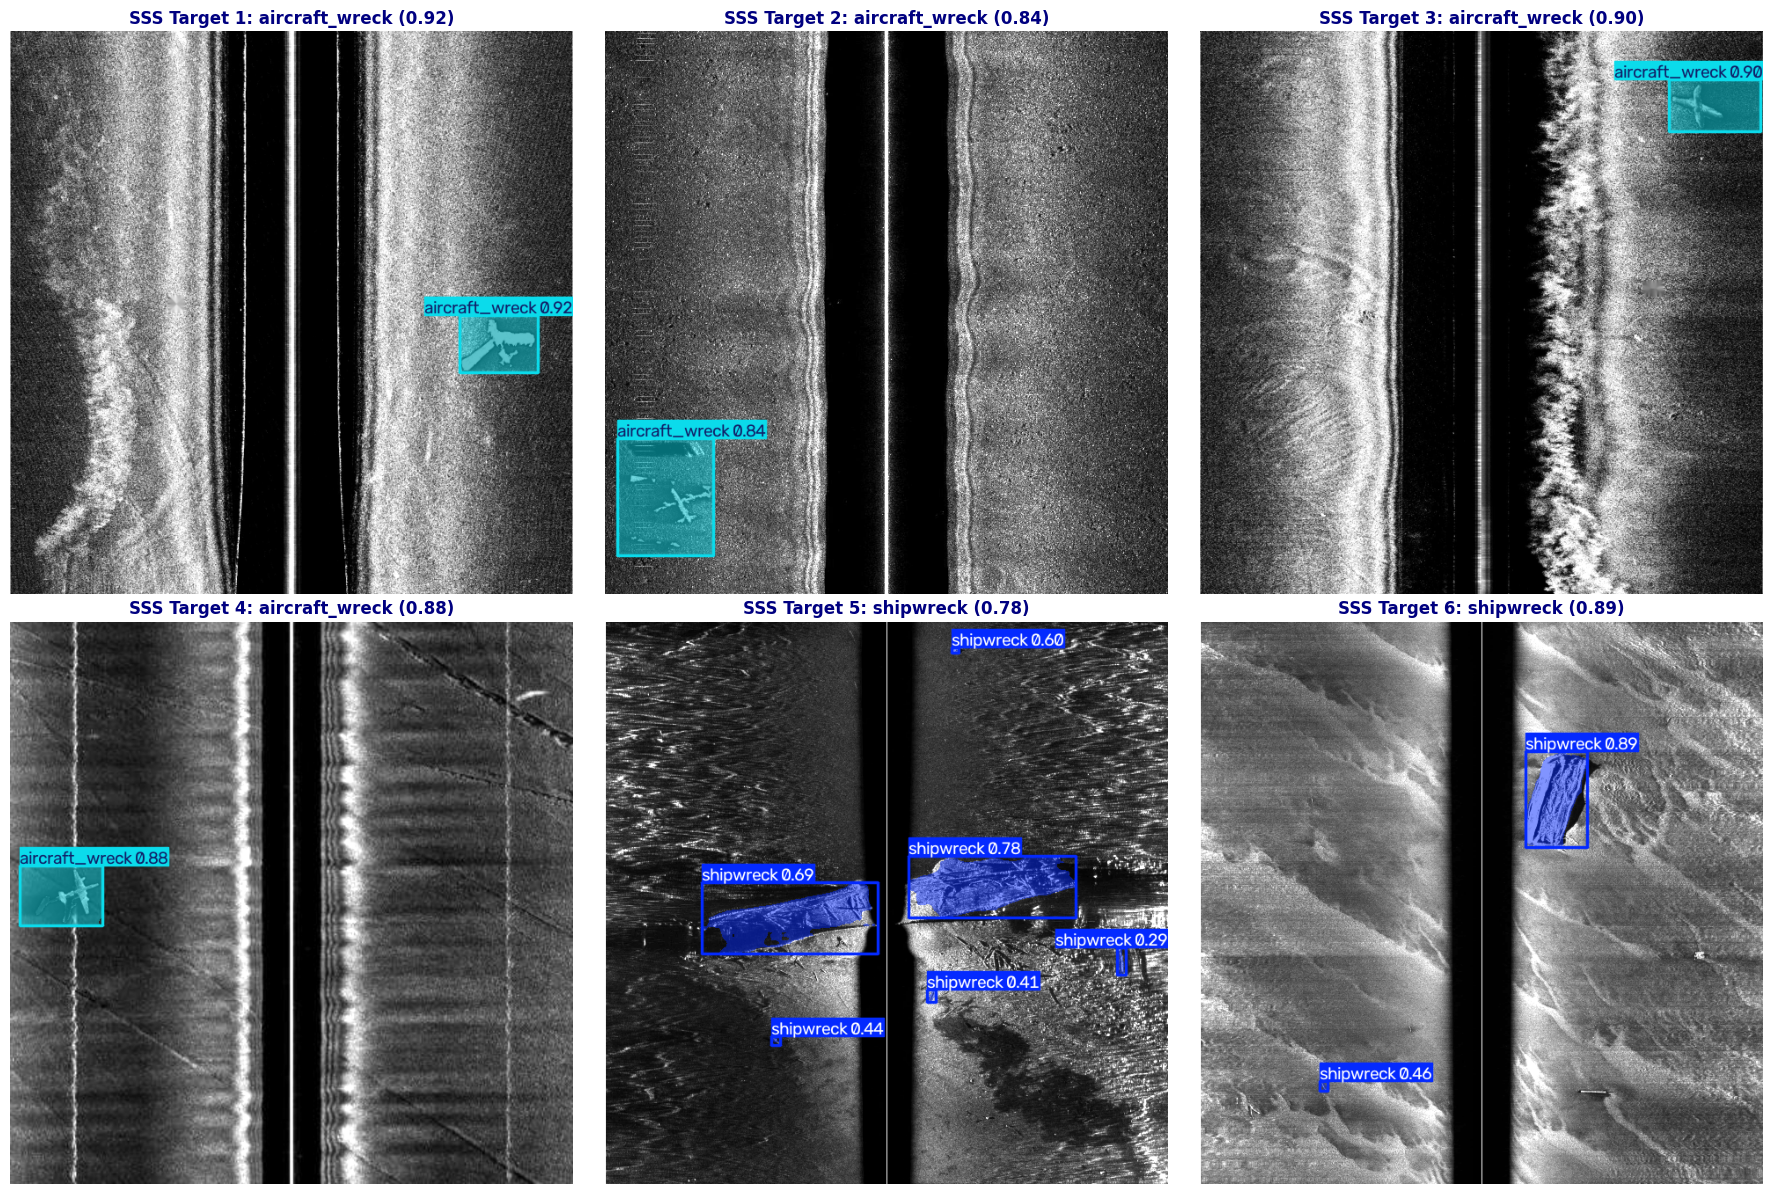

In [ ]:
import os, random
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

img_dir = Path('/content/custom_val_samples/images')
lbl_dir = Path('/content/custom_val_samples/labels')

# 1. Load trained model
weights_path = '/content/drive/MyDrive/NayanSagar_AI/runs/yolo11s_balanced_v2/weights/best.pt'
model = YOLO(weights_path)

# 2. Gather candidates strictly from Side-Scan Sonar (SSS)
# Exclude forward-looking sonar (FLS) wedge-shaped acoustic images
candidate_imgs = []

for lbl_file in lbl_dir.glob('*.txt'):
    fname = lbl_file.stem.lower()

    # Filter OUT forward-looking sonar (wedge/fan) files
    if 'fls' in fname or 'forward' in fname:
        continue

    with open(lbl_file, 'r') as f:
        lines = [line.strip().split() for line in f if line.strip()]

    if not lines:
        continue

    classes = [int(l[0]) for l in lines]

    # Look for aircraft_wreck (1), ghost_net (3), or shipwreck (0)
    if 1 in classes or 3 in classes or 0 in classes:
        matches = list(img_dir.glob(f"{lbl_file.stem}.*"))
        if matches:
            img_p = matches[0]
            im = cv2.imread(str(img_p), cv2.IMREAD_GRAYSCALE)

            # SSS check: avoid fan/wedge masks where large outer corners are completely black (zeros)
            if im is not None:
                h, w = im.shape
                corner_sum = im[:20, :20].mean() + im[:20, -20:].mean() # Top corners

                # Rectangular SSS has texture everywhere; FLS fan shape has solid black top corners
                if corner_sum > 5 and im.std() > 22:
                    candidate_imgs.append(img_p)

print(f"Found {len(candidate_imgs)} pure Side-Scan Sonar (SSS) target candidates.")

# Shuffle to ensure a fresh selection each run
random.seed()
random.shuffle(candidate_imgs)

# 3. Predict and filter for 6 high-quality detections
selected_results = []
for img_p in candidate_imgs:
    res = model.predict(source=str(img_p), conf=0.25, iou=0.45, verbose=False)[0]

    if len(res.boxes) > 0:
        max_conf = float(res.boxes.conf.max())
        # Pick solid detections with clear boundaries
        if max_conf >= 0.45:
            selected_results.append(res)

    if len(selected_results) == 6:
        break

# 4. Display 6 images in a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (res, ax) in enumerate(zip(selected_results, axes)):
    annotated_bgr = res.plot(line_width=2, font_size=1)
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

    classes_present = [model.names[int(b.cls)] for b in res.boxes]
    top_conf = float(res.boxes.conf.max())

    title_text = f"SSS Target {idx+1}: {classes_present[0]} ({top_conf:.2f})"
    if len(set(classes_present)) > 1:
        title_text += f" + {len(classes_present)-1} more"

    ax.imshow(annotated_rgb)
    ax.axis('off')
    ax.set_title(title_text, fontsize=12, fontweight='bold', color='navy')

plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import cv2

# Create demo assets folder in Drive
demo_dir = Path('/content/drive/MyDrive/NayanSagar_AI/demo_assets')
raw_demo_dir = demo_dir / 'raw_tiles'
annotated_demo_dir = demo_dir / 'annotated_tiles'

raw_demo_dir.mkdir(parents=True, exist_ok=True)
annotated_demo_dir.mkdir(parents=True, exist_ok=True)

for idx, res in enumerate(selected_results):
    orig_path = Path(res.path)

    # 1. Save the clean raw original image (for judge live testing in the app)
    raw_img = cv2.imread(str(orig_path))
    raw_save_path = raw_demo_dir / f"demo_target_{idx+1}_{orig_path.stem}.png"
    cv2.imwrite(str(raw_save_path), raw_img)

    # 2. Save the model-annotated image (for your presentation slides)
    ann_img = res.plot(line_width=2, font_size=1)
    ann_save_path = annotated_demo_dir / f"pred_target_{idx+1}_{orig_path.stem}.png"
    cv2.imwrite(str(ann_save_path), ann_img)

print(f"[✓] Saved {len(selected_results)} raw demo tiles to: {raw_demo_dir}")
print(f"[✓] Saved {len(selected_results)} annotated preview tiles to: {annotated_demo_dir}")

[✓] Saved 6 raw demo tiles to: /content/drive/MyDrive/NayanSagar_AI/demo_assets/raw_tiles
[✓] Saved 6 annotated preview tiles to: /content/drive/MyDrive/NayanSagar_AI/demo_assets/annotated_tiles


In [ ]:
# Create a single zip package with both weights and demo tiles
!zip -j /content/drive/MyDrive/NayanSagar_AI/NayanSagar_Deployment_Assets.zip \
  /content/drive/MyDrive/NayanSagar_AI/runs/yolo11s_balanced_v2/weights/best.pt \
  /content/drive/MyDrive/NayanSagar_AI/runs/yolo11s_balanced_v2/weights/best.onnx \
  /content/drive/MyDrive/NayanSagar_AI/demo_assets/raw_tiles/*
print("[✓] Deployment bundle created in Drive: NayanSagar_Deployment_Assets.zip")

  adding: best.pt (deflated 8%)
  adding: best.onnx (deflated 15%)
  adding: demo_target_1_dataset_sss_wrecks_aircraft_plane-306_24.png (deflated 11%)
  adding: demo_target_2_dataset_sss_wrecks_aircraft_plane-202_45.png (deflated 12%)
  adding: demo_target_3_dataset_sss_wrecks_aircraft_plane-311_148.png (deflated 12%)
  adding: demo_target_4_dataset_sss_wrecks_aircraft_plane-147_156.png (deflated 19%)
  adding: demo_target_5_AI4Shipwrecks_WP_Rend_04_756.png (deflated 15%)
  adding: demo_target_6_AI4Shipwrecks_Barge_No_1_15_397.png (deflated 15%)
[✓] Deployment bundle created in Drive: NayanSagar_Deployment_Assets.zip


unsupervised model

In [ ]:
from google.colab import drive
import os, shutil
from pathlib import Path

# 1. Mount Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Create scratch directory for unsupervised training data
scratch_data = Path('/content/unsupervised_data')
scratch_normal = scratch_data / 'normal_seabed'
if scratch_data.exists():
    shutil.rmtree(scratch_data)
scratch_normal.mkdir(parents=True, exist_ok=True)

# 3. Unpack images from your balanced dataset archive
print("Unpacking dataset from Drive to fast SSD...")
!unzip -q -j "/content/drive/MyDrive/NayanSagar_AI/NayanSagar_Dataset_v2_Balanced.zip" "*/images/train/*" -d "/content/unsupervised_data/all_train"
!unzip -q -j "/content/drive/MyDrive/NayanSagar_AI/NayanSagar_Dataset_v2_Balanced.zip" "*/labels/train/*" -d "/content/unsupervised_data/all_labels"

# 4. Filter for empty/normal seabed tiles (tiles with NO labels or marked as hard negatives)
all_imgs = list(Path('/content/unsupervised_data/all_train').glob('*.*'))
lbl_dir = Path('/content/unsupervised_data/all_labels')

normal_count = 0
for img_p in all_imgs:
    lbl_file = lbl_dir / f"{img_p.stem}.txt"
    # An image is normal seabed if it has no label file OR an empty label file (0 lines)
    if not lbl_file.exists() or os.path.getsize(lbl_file) == 0:
        shutil.copy(str(img_p), str(scratch_normal / img_p.name))
        normal_count += 1

print(f"[✓] Successfully isolated {normal_count} clean normal seabed tiles for unsupervised learning!")

Mounted at /content/drive
Unpacking dataset from Drive to fast SSD...
[✓] Successfully isolated 325 clean normal seabed tiles for unsupervised learning!


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

# Dataset loader
class NormalSeabedDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.files = list(Path(folder).glob('*.*'))
        self.transform = transform
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert('L')
        if self.transform:
            img = self.transform(img)
        return img

# Lightweight Autoencoder Network (~1.8 MB)
class SonarAutoencoder(nn.Module):
    def __init__(self):
        super(SonarAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # -> 128x128
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.2),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # -> 64x64
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # -> 32x32
            nn.LeakyReLU(0.2)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), # -> 64x64
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # -> 128x128
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),  # -> 256x256
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

# Training Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ae_model = SonarAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3)

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

train_loader = DataLoader(NormalSeabedDataset(scratch_normal, transform=transform), batch_size=32, shuffle=True)

print(f"Training on device: {device}...")
ae_model.train()
for epoch in range(30):
    running_loss = 0.0
    for imgs in train_loader:
        imgs = imgs.to(device)
        recon = ae_model(imgs)
        loss = criterion(recon, imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/30] - Reconstruction Loss: {running_loss/len(train_loader):.5f}")

# Save the trained autoencoder directly to Drive
ae_save_path = '/content/drive/MyDrive/NayanSagar_AI/runs/sonar_autoencoder.pt'
torch.save(ae_model.state_dict(), ae_save_path)
print(f"[✓] Autoencoder weights saved to Drive: {ae_save_path}")

Training on device: cuda...
Epoch [5/30] - Reconstruction Loss: 0.00861
Epoch [10/30] - Reconstruction Loss: 0.00489
Epoch [15/30] - Reconstruction Loss: 0.00378
Epoch [20/30] - Reconstruction Loss: 0.00342
Epoch [25/30] - Reconstruction Loss: 0.00298
Epoch [30/30] - Reconstruction Loss: 0.00285
[✓] Autoencoder weights saved to Drive: /content/drive/MyDrive/NayanSagar_AI/runs/sonar_autoencoder.pt


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 7.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


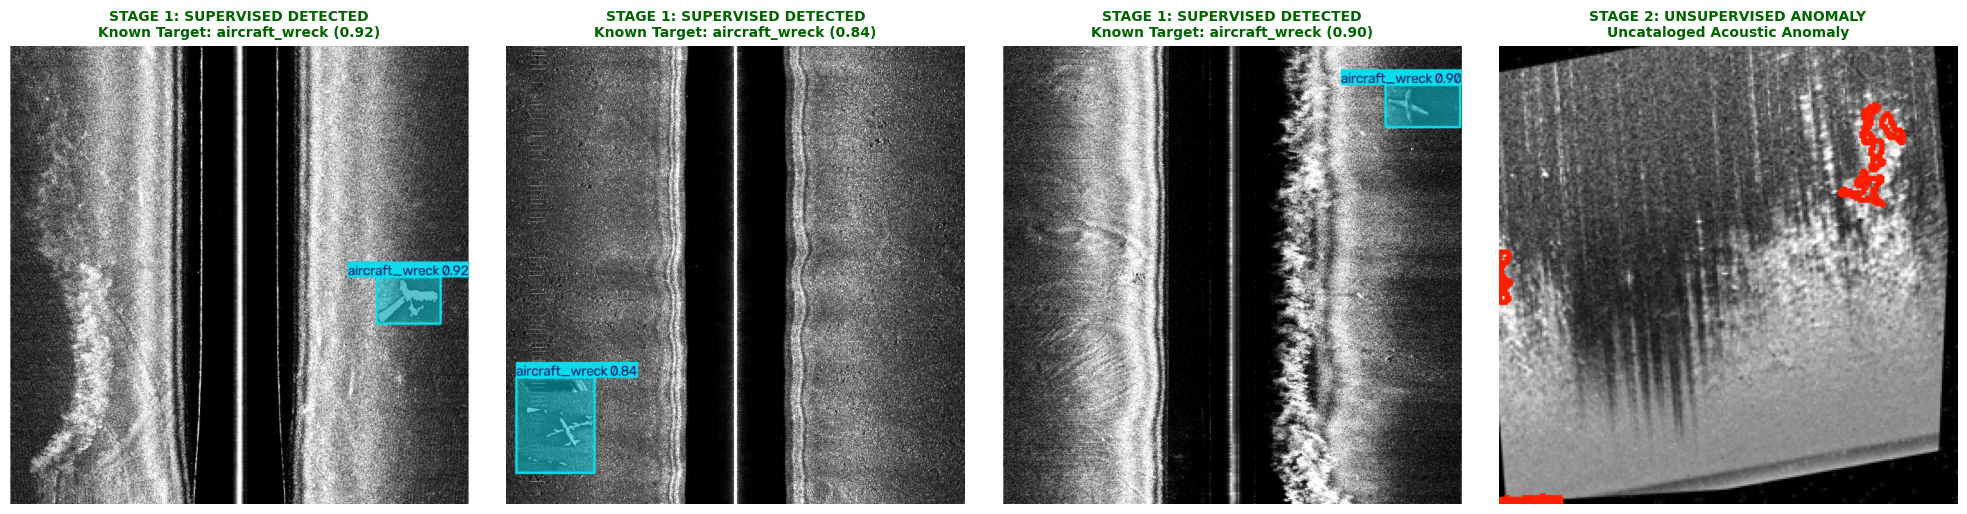

In [ ]:
# 1. Install ultralytics in the active runtime
!pip install -q "ultralytics>=8.3.0"

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import torch
from torchvision import transforms
from ultralytics import YOLO

# 2. Setup device & image transform
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# 3. Load trained supervised YOLO11s-seg
yolo_path = '/content/drive/MyDrive/NayanSagar_AI/runs/yolo11s_balanced_v2/weights/best.pt'
yolo_model = YOLO(yolo_path)

# 4. Load trained unsupervised Autoencoder
ae_model = SonarAutoencoder().to(device)
ae_model.load_state_dict(torch.load('/content/drive/MyDrive/NayanSagar_AI/runs/sonar_autoencoder.pt', map_location=device))
ae_model.eval()

# 5. Dual Pipeline Inference Function
def run_dual_inspection(img_path, conf_thresh=0.20):
    # Pass 1: Supervised YOLO11s-seg
    res = yolo_model.predict(source=str(img_path), conf=conf_thresh, verbose=False)[0]

    if len(res.boxes) > 0:
        annotated_bgr = res.plot(line_width=2)
        top_cls = yolo_model.names[int(res.boxes.cls[0])]
        top_conf = float(res.boxes.conf[0])
        return (
            "STAGE 1: SUPERVISED DETECTED",
            cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB),
            f"Known Target: {top_cls} ({top_conf:.2f})"
        )

    # Pass 2: Unsupervised Reconstruction Fallback
    pil_img = Image.open(img_path).convert('L')
    tensor_in = transform(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        tensor_out = ae_model(tensor_in)

    diff = torch.abs(tensor_in - tensor_out).squeeze().cpu().numpy()
    diff_blur = cv2.GaussianBlur(diff, (9, 9), 0)
    thresh_val = np.percentile(diff_blur, 98.2)
    mask = (diff_blur > thresh_val).astype(np.uint8) * 255

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    significant_anomalies = [c for c in contours if cv2.contourArea(c) > 60]

    rgb_display = cv2.cvtColor(np.array(pil_img.resize((256, 256))), cv2.COLOR_GRAY2RGB)
    if significant_anomalies:
        cv2.drawContours(rgb_display, significant_anomalies, -1, (255, 30, 0), 2)
        return (
            "STAGE 2: UNSUPERVISED ANOMALY",
            rgb_display,
            "Uncataloged Acoustic Anomaly"
        )
    else:
        return (
            "STAGE 2: NORMAL SEABED",
            rgb_display,
            "Clean Seafloor Verified"
        )

# 6. Run inference on test targets + 1 empty seabed tile
test_tiles = list(Path('/content/drive/MyDrive/NayanSagar_AI/demo_assets/raw_tiles').glob('*.png'))[:3]
normal_tiles = list(Path('/content/unsupervised_data/normal_seabed').glob('*.*'))[:1]
all_test_tiles = test_tiles + normal_tiles

fig, axes = plt.subplots(1, len(all_test_tiles), figsize=(20, 5))
if len(all_test_tiles) == 1:
    axes = [axes]

for ax, t_path in zip(axes, all_test_tiles):
    stage, out_img, label = run_dual_inspection(t_path)
    ax.imshow(out_img)
    ax.axis('off')
    color = 'darkgreen' if 'SUPERVISED' in stage else ('red' if 'ANOMALY' in stage else 'blue')
    ax.set_title(f"{stage}\n{label}", fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Install required ONNX export dependencies
!pip install -q onnx onnxscript

import torch
import torch.nn as nn

# 2. Re-verify model definition for CPU export
class SonarAutoencoder(nn.Module):
    def __init__(self):
        super(SonarAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.2),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

# 3. Load trained weights to CPU
ae_model = SonarAutoencoder().to('cpu')
ae_weights_path = '/content/drive/MyDrive/NayanSagar_AI/runs/sonar_autoencoder.pt'
ae_model.load_state_dict(torch.load(ae_weights_path, map_location='cpu'))
ae_model.eval()

# 4. Export to ONNX
dummy_input = torch.randn(1, 1, 256, 256)
onnx_ae_path = '/content/drive/MyDrive/NayanSagar_AI/runs/sonar_autoencoder.onnx'

torch.onnx.export(
    ae_model,
    dummy_input,
    onnx_ae_path,
    export_params=True,
    opset_version=14,
    do_constant_folding=True,
    input_names=['input_sonar_tile'],
    output_names=['reconstructed_seabed'],
    dynamic_axes={'input_sonar_tile': {0: 'batch_size'}, 'reconstructed_seabed': {0: 'batch_size'}}
)

print(f"[✓] Autoencoder ONNX export successfully created at:\n{onnx_ae_path}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 17.0 MB/s eta 0:00:00


/tmp/ipykernel_624/2623685642.py:44: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0909 19:31:49.588000 624 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `SonarAutoencoder([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SonarAutoencoder([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        proto, target_version=self.target_version
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/onnx/version

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
[✓] Autoencoder ONNX export successfully created at:
/content/drive/MyDrive/NayanSagar_AI/runs/sonar_autoencoder.onnx
